In [1]:
#importing cell

import CommunityModelClass3 as cmc3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import clear_output
import csv

dir_name = 'NicheOverlap_data'

Set inputs for the Simulations

In [2]:
inputs = {}

inputs["S_tot"]=80
inputs["S"] = 40
inputs["R"] = 40

# initial conditions
inputs["S0"] = 10
inputs["R0"] = 5

# time simulation params
inputs["time_period"] = 1e5
inputs["t_step"] = 0.1

# partitions params
inputs["num_F"] = 4
inputs["num_T"] = 4
inputs["partition_F"] = [20]*4
inputs["partition_T"] = [10]*4

# activation function
inputs["sigma_type"] = "linear"
inputs["k"] = 20                           
inputs["N"] = 2

# h function params
inputs["tau_R"] = 1
inputs["k_alpha_index"] = 0
inputs["k_0"] = 1000 

# metabolic matrix params
inputs["f_c"] = 0.25
inputs["f_s"] = 0.25
inputs["d0"] = 0.2

# preference matrix params
inputs["preference_type"] = "binary"
inputs["c_0"] = 1
inputs["mu_c"] = 4.5
inputs["sigma_c"] = 0.3
inputs["q_A"] = 0.5

inputs["k_0"] = 10
inputs["leakage"] = 0.001

c1_ex1, c1_ex2 = 0.33, 0.8
inputs["c_1"] = c1_ex1
model_ex1 = cmc3.CommunityModel(inputs)
model_ex1.Simulate()
inputs["c_1"] = c1_ex2
model_ex2 = cmc3.CommunityModel(inputs)
model_ex2.Simulate()

## Niche Overlaps Analysis

We have observed from previous simulations how, in the case of the "Restricted Regime," the number of surviving species is limited due to a low metabolic leakage or a low energy supply in the environment. However, there seems to be a limitation even in the "Diverse Regime," despite having high energy supply and leakage values. In fact, although the competitive exclusion principle imposes a theoretical limit on the number of resources, the average number of surviving species at equilibrium is much lower. 

This phenomenon can be explained by the preference matrix and the similarity in preferences among species. If multiple species have similar preferences, only one of them is destined to outcompete the others. Let us calculate the degree of similarity in our environment using *Niche Overlap*, computed as follows:

$$
\left\langle\rho_{i j}\right\rangle \equiv\left\langle\frac{\sum_\alpha c_{i \alpha} c_{j \alpha}}{\sqrt{\sum_\alpha c_{i \alpha}^2 \sum_\alpha c_{j \alpha}^2}}\right\rangle=\frac{\left\langle c_{i \alpha}\right\rangle^2}{\sqrt{\left\langle c_{i \alpha}^2\right\rangle\left\langle c_{j \alpha}^2\right\rangle}}
$$

In our simulations, it is possible to adjust the similarity of the preference matrix and, thus, the value of the Niche Overlap, through the parameter $c_1$, as explained earlier. We logarithmically varied the value of $c_1$ from 1 to 0.33, starting with highly heterogeneous preference matrices and gradually transitioning to more homogeneous ones with similar preferences among species.

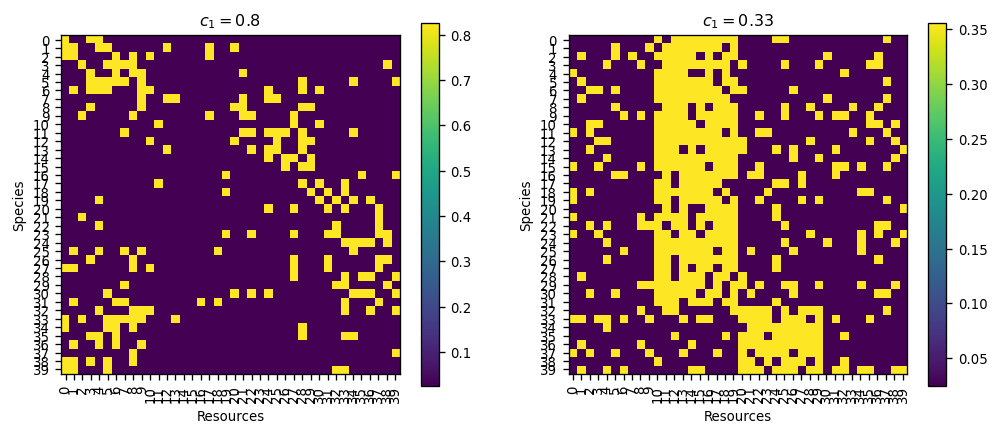

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
model_ex1.ReturnCommunityPreferenceMatrix("graphical", figsize=(4,4), title=f'$c_1 = {c1_ex1}$', ax=ax[1])
model_ex2.ReturnCommunityPreferenceMatrix("graphical", figsize=(4,4), title=f'$c_1 = {c1_ex2}$', ax=ax[0])

Therefore, we expect that as the preferences among species become increasingly similar, the value of the *Richness* (the number of surviving species at equilibrium) will decrease due to escalating competition among species.

**About the simulations:**

We set up 20 preference matrices with high homogeneity, resulting in low Niche Overlap, and conducted simulations in two environments: 10 in Diverse Regime and 10 in Restricted Regime. Subsequently, we gradually decreased the value of $c_1$ (thus making the matrices increasingly homogeneous). The graphs below depict the simulations described above.

### Comparison Restricted Regime and Diverse Regime

In [4]:
#Load Simulation Results
Niches_DR = np.loadtxt(f'{dir_name}/Niches_RR.csv', delimiter=',')
Niches_RR = np.loadtxt(f'{dir_name}/Niches_DR.csv', delimiter=',')
survived_array_RR = np.loadtxt(f'{dir_name}/survived_array_RR.csv', delimiter=',')
survived_array_DR = np.loadtxt(f'{dir_name}/survived_array_DR.csv', delimiter=',')

In [5]:
# Load optimal parameters from data
popt_RR = np.loadtxt(f'{dir_name}/popt_RR.csv', delimiter=',')
popt_DR = np.loadtxt(f'{dir_name}/popt_DR.csv', delimiter=',')

--------------------------------------------------------------------------------------

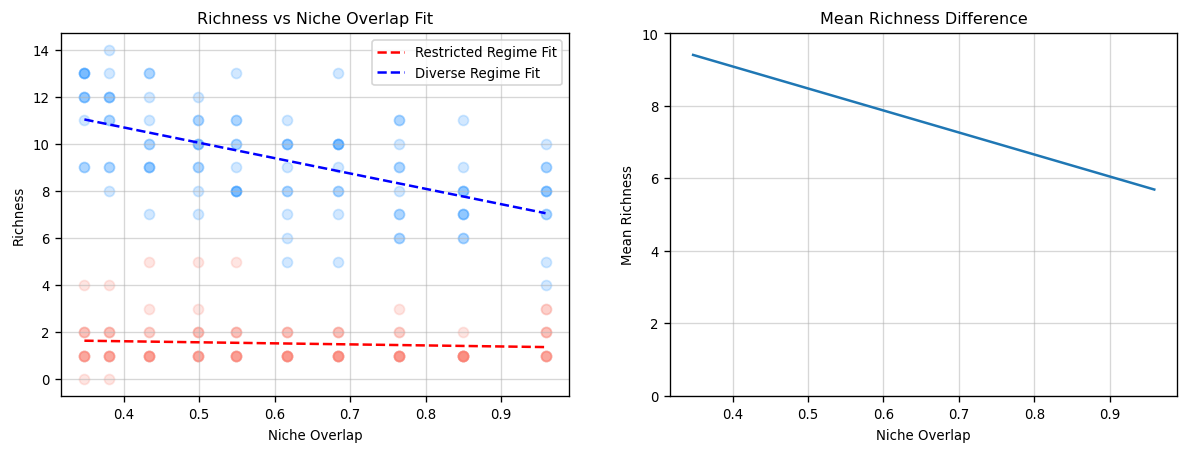

In [8]:
def lin_func(x, m, q):
    return q + m * x

num_simulations = survived_array_DR.shape[0]
Niches_RR = list(Niches_RR)
Niches_DR = list(Niches_DR)

x_RR = np.linspace(np.min(Niches_RR), np.max(Niches_RR), num=100)
y_RR = lin_func(x_RR, popt_RR[0], popt_RR[1])
x_DR = np.linspace(np.min(Niches_DR), np.max(Niches_DR), num=100)
y_DR = lin_func(x_DR, popt_DR[0], popt_DR[1])
distance = y_DR-y_RR

fig, ax = plt.subplots(1,2,figsize=(12,4))
# Plot real data
ax[0].set(title='Richness vs Niche Overlap Fit',xlabel='Niche Overlap',ylabel='Richness')
ax[0].scatter(Niches_RR*num_simulations, survived_array_RR.flatten(), c='salmon', alpha=0.2)
ax[0].scatter(Niches_DR*num_simulations, survived_array_DR.flatten(), c='dodgerblue', alpha=0.2)
# Plot fit
ax[0].plot(x_RR, y_RR, 'r--', label='Restricted Regime Fit')
ax[0].plot(x_DR, y_DR, 'b--', label='Diverse Regime Fit')
ax[0].legend()
ax[0].grid(alpha=0.5)

ax[1].set(title='Mean Richness Difference',xlabel='Niche Overlap',ylabel='Mean Richness')
ax[1].plot(x_DR,distance)
ax[1].set_ylim(0,10)
ax[1].grid(alpha=0.5)


In the diverse regime, there is an observed linear decrease in mean species richness with increasing niche overlap. Conversely, the richness of the resource-limited regime exhibits only a minimal dependence on niche overlap. These results suggest that the distribution of consumption preferences within the regional pool is the predominant driver of community assembly in the diverse regime. 